Saving BASE_YEIMY.xlsx to BASE_YEIMY.xlsx
Datos: (99, 141) | Años: [np.int64(2023), np.int64(2024), np.int64(2025)]
Variables seleccionadas: 29

─────────────────────────────────────────────────────────────────
Variable                  Pooled   Ef.Fijos   Ef.Aleat.
─────────────────────────────────────────────────────────────────
INS-3-2                  -0.394      +0.093       -0.424   
INS-3                    -0.302      +0.360       -0.343   
INS-4-1                  +0.905***   +0.470       +0.939***
INS-4-6                  -0.665**    -0.360       -0.710***
INF-1-3                  -1.700***   +0.753       -1.623***
INF-1-4                  -0.772      -1.650**     -0.785   
INF-1-5                  -0.970      -2.556       -0.791   
INF-1                    +1.570      +8.606**     +1.339   
INF-2                    -0.704      -0.994       -0.740   
INF                      -0.210      -0.222       -0.144   
TIC-1-4                  -1.189*     +0.952       -1.261** 
SAL-1-3

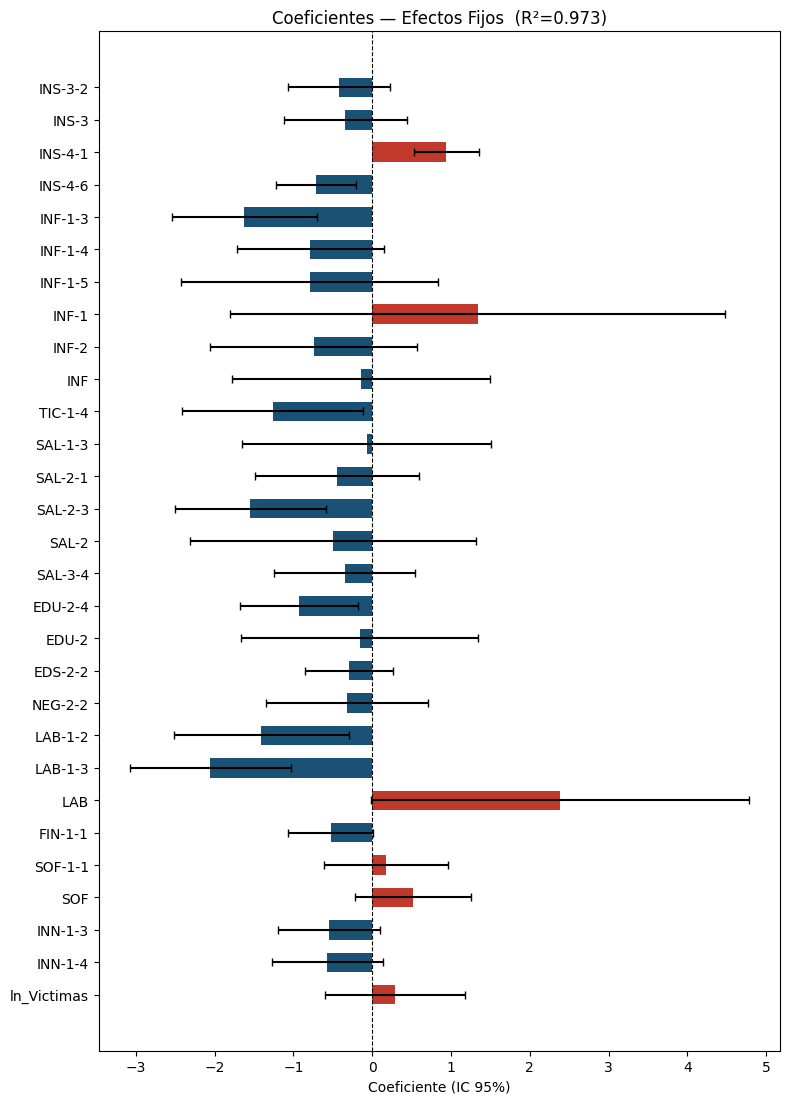

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Archivos descargados.

═════════════════════════════════════════════════════════════════
PRUEBAS DE ROBUSTEZ
═════════════════════════════════════════════════════════════════

PRUEBA 1 — Breusch-Pagan (heterocedasticidad)
  LM = 20.5160  |  p = 0.8762
  → ✓  No hay heterocedasticidad

PRUEBA 2 — Autocorrelación (Wooldridge)
  ρ promedio = -0.5152  |  H0: ρ = -0.5000  |  p = 0.9197
  → ✓  No hay autocorrelación serial

PRUEBA 3 — SE Robustos Clusterizados (por departamento)
Variable                   β FE   SE rob.       t       p  sig
───────────────────────────────────────────────────────
INS-3-2                  +0.093    0.3697   0.250  0.8040     
INS-3                    +0.360    0.3742   0.961  0.3437     
INS-4-1                  +0.470    0.3372   1.393  0.1731     
INS-4-6                  -0.360    0.3087  -1.167  0.2520     
INF-1-3                  +0.753    1.3441   0.560  0.5794     
INF-1-4                  -1.650    0.5580  -2.957  0.0058  ***
INF-1-5                

In [1]:
# ── Subir archivo ─────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # sube BASE_YEIMY.xlsx

# ── Librerías ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_excel(list(uploaded.keys())[0])
print(f"Datos: {df.shape} | Años: {sorted(df['Año IDC'].unique())}")

# ── Preparar variables ────────────────────────────────────────────────────────
y = df["IPM"].values
df["ln_Victimas"] = np.log1p(df["Victimas"])

# Features: todo excepto identificadores y dependiente
excl = ["Departamento", "Año IDC", "IPM", "Victimas"]
feat = [c for c in df.columns if c not in excl]

# Eliminar columnas con >10% NaN e imputar el resto con mediana
feat = [c for c in feat if df[c].isna().mean() <= 0.10]
df[feat] = df[feat].fillna(df[feat].median())

# ── LASSO para seleccionar variables ─────────────────────────────────────────
X = StandardScaler().fit_transform(df[feat].values)
lasso = LassoCV(cv=3, n_alphas=30, max_iter=3000).fit(X, y)
seleccionadas = [feat[i] for i, c in enumerate(lasso.coef_) if c != 0]
if "ln_Victimas" not in seleccionadas:
    seleccionadas = ["ln_Victimas"] + seleccionadas
print(f"Variables seleccionadas: {len(seleccionadas)}")

X = df[seleccionadas].values
N, k = len(df), len(seleccionadas)
depts = df["Departamento"].values
ids   = pd.factorize(depts)[0]
n_d   = len(np.unique(ids))
T     = N // n_d

# ── Pooled OLS ────────────────────────────────────────────────────────────────
Xc   = np.column_stack([np.ones(N), X])
b, *_ = np.linalg.lstsq(Xc, y, rcond=None)
res  = y - Xc @ b
s2   = res.var()
se   = np.sqrt(np.diag(np.linalg.pinv(Xc.T @ Xc) * s2 * N / (N-k-1)))
r2_pool = 1 - np.var(res) / np.var(y)

# ── Efectos Fijos (demeaning) ─────────────────────────────────────────────────
def demean(arr, ids):
    out = arr.copy().astype(float)
    for i in np.unique(ids):
        mask = ids == i
        out[mask] -= out[mask].mean(axis=0)
    return out

Xdm, ydm = demean(X, ids), demean(y, ids)
b_fe, *_ = np.linalg.lstsq(Xdm, ydm, rcond=None)
res_fe   = ydm - Xdm @ b_fe
s2_fe    = np.sum(res_fe**2) / (N - k - n_d)
se_fe    = np.sqrt(np.diag(np.linalg.pinv(Xdm.T @ Xdm) * s2_fe))
t_fe     = b_fe / se_fe
p_fe     = 2 * (1 - stats.t.cdf(np.abs(t_fe), df=N-k-n_d))
r2_fe    = 1 - np.var(res_fe) / np.var(ydm)

# ── Efectos Aleatorios (GLS) ──────────────────────────────────────────────────
means    = pd.DataFrame(np.column_stack([ids, X, y])).groupby(0).mean().values
Xb, yb   = np.column_stack([np.ones(n_d), means[:, :-1]]), means[:, -1]
b_be, *_ = np.linalg.lstsq(Xb, yb, rcond=None)
s2_b     = np.var(yb - Xb @ b_be)
theta    = 1 - np.sqrt(s2_fe / (s2_fe + (N/n_d) * s2_b))

Xqd = X - theta * demean(X, ids)
yqd = y - theta * demean(y, ids)
Xqdc     = np.column_stack([np.ones(N), Xqd])
b_re, *_ = np.linalg.lstsq(Xqdc, yqd, rcond=None)
res_re   = yqd - Xqdc @ b_re
s2_re    = np.sum(res_re**2) / (N - k - 1)
se_re    = np.sqrt(np.diag(np.linalg.pinv(Xqdc.T @ Xqdc) * s2_re))
t_re     = b_re / se_re
p_re     = 2 * (1 - stats.t.cdf(np.abs(t_re), df=N-k-1))
r2_re    = 1 - np.var(res_re) / np.var(yqd)

# ── Hausman ───────────────────────────────────────────────────────────────────
diff  = b_fe - b_re[1:]
V_dif = np.linalg.pinv(Xdm.T @ Xdm)*s2_fe - np.linalg.pinv(Xqdc.T @ Xqdc)[1:,1:]*s2_re
H     = float(diff @ np.linalg.pinv(V_dif) @ diff)
p_H   = 1 - stats.chi2.cdf(H, df=k)
recom = "Efectos Fijos" if p_H < 0.05 else "Efectos Aleatorios"

# ── Resultados ────────────────────────────────────────────────────────────────
def sig(p): return "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""

print(f"\n{'─'*65}")
print(f"{'Variable':<22} {'Pooled':>9} {'Ef.Fijos':>10} {'Ef.Aleat.':>11}")
print(f"{'─'*65}")
for i, v in enumerate(seleccionadas):
    print(f"{v:<22} {b[i+1]:>+8.3f}{sig(2*(1-stats.t.cdf(abs(b[i+1]/se[i+1]),N-k-1))):3}"
          f" {b_fe[i]:>+8.3f}{sig(p_fe[i]):3}"
          f"  {b_re[i+1]:>+8.3f}{sig(p_re[i+1]):3}")
print(f"{'─'*65}")
print(f"{'R²':<22} {r2_pool:>9.3f} {r2_fe:>10.3f} {r2_re:>11.3f}")
print(f"\nHausman: H={H:.2f}, p={p_H:.3f}  →  Modelo preferido: {recom}")
print("*** p<0.01  ** p<0.05  * p<0.10")

# ── Gráfico ───────────────────────────────────────────────────────────────────
colores = ["#C0392B" if b>0 else "#1A5276" for b in b_re[1:]]
plt.figure(figsize=(8, k*0.35 + 1))
plt.barh(seleccionadas[::-1], b_re[1:][::-1],
         xerr=1.96*se_re[1:][::-1], color=colores[::-1],
         capsize=3, height=0.6)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title(f"Coeficientes — {recom}  (R²={r2_re:.3f})", fontsize=12)
plt.xlabel("Coeficiente (IC 95%)")
plt.tight_layout()
plt.savefig("resultados_panel.png", dpi=130)
plt.show()

# ── Exportar ──────────────────────────────────────────────────────────────────
tabla = pd.DataFrame({
    "Variable":   seleccionadas,
    "Pooled β":   [f"{b[i+1]:+.3f}{sig(2*(1-stats.t.cdf(abs(b[i+1]/se[i+1]),N-k-1)))}" for i in range(k)],
    "FE β":       [f"{b_fe[i]:+.3f}{sig(p_fe[i])}" for i in range(k)],
    "RE β":       [f"{b_re[i+1]:+.3f}{sig(p_re[i+1])}" for i in range(k)],
})
tabla.to_excel("resultados_panel.xlsx", index=False)
files.download("resultados_panel.xlsx")
files.download("resultados_panel.png")
print("✓ Archivos descargados.")

# ══════════════════════════════════════════════════════════════════════════════
# ── PRUEBAS DE ROBUSTEZ ───────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*65}")
print("PRUEBAS DE ROBUSTEZ")
print(f"{'═'*65}")

# ── PRUEBA 1: Breusch-Pagan (heterocedasticidad) ──────────────────────────────
res_sq = res_fe**2
Xc_bp  = np.column_stack([np.ones(N), Xdm])
b_bp, *_ = np.linalg.lstsq(Xc_bp, res_sq, rcond=None)
yhat_bp  = Xc_bp @ b_bp
ss_reg   = np.sum((yhat_bp - np.mean(res_sq))**2)
ss_tot   = np.sum((res_sq  - np.mean(res_sq))**2)
r2_bp    = ss_reg / ss_tot if ss_tot > 0 else 0
LM_bp    = N * r2_bp
p_bp     = 1 - stats.chi2.cdf(LM_bp, df=k)
print(f"\nPRUEBA 1 — Breusch-Pagan (heterocedasticidad)")
print(f"  LM = {LM_bp:.4f}  |  p = {p_bp:.4f}")
print(f"  → {'⚠️  Heterocedasticidad detectada' if p_bp < 0.05 else '✓  No hay heterocedasticidad'}")

# ── PRUEBA 2: Autocorrelación (Wooldridge simplificado) ───────────────────────
corrs = []
for dept_id in np.unique(ids):
    mask = ids == dept_id
    r    = res_fe[mask]
    if len(r) > 1:
        corrs.append(np.corrcoef(r[:-1], r[1:])[0, 1])

rho_mean = np.mean(corrs)
rho_H0   = -1 / (T - 1)
se_rho   = np.std(corrs) / np.sqrt(len(corrs))
t_rho    = (rho_mean - rho_H0) / se_rho if se_rho > 0 else 0
p_rho    = 2 * (1 - stats.t.cdf(abs(t_rho), df=len(corrs)-1))
print(f"\nPRUEBA 2 — Autocorrelación (Wooldridge)")
print(f"  ρ promedio = {rho_mean:.4f}  |  H0: ρ = {rho_H0:.4f}  |  p = {p_rho:.4f}")
print(f"  → {'⚠️  Autocorrelación detectada' if p_rho < 0.05 else '✓  No hay autocorrelación serial'}")

# ── PRUEBA 3: Errores estándar robustos clusterizados por departamento ─────────
meat = np.zeros((k, k))
for dept_id in np.unique(ids):
    mask     = ids == dept_id
    Xi       = Xdm[mask]
    ei       = res_fe[mask]
    score_i  = Xi.T @ ei
    meat    += np.outer(score_i, score_i)

bread     = np.linalg.pinv(Xdm.T @ Xdm)
V_cluster = bread @ meat @ bread
V_cluster *= (n_d / (n_d - 1)) * ((N - 1) / (N - k))
se_rob    = np.sqrt(np.diag(V_cluster))
t_rob     = b_fe / se_rob
p_rob     = 2 * (1 - stats.t.cdf(np.abs(t_rob), df=n_d - 1))

print(f"\nPRUEBA 3 — SE Robustos Clusterizados (por departamento)")
print(f"{'Variable':<22} {'β FE':>8} {'SE rob.':>9} {'t':>7} {'p':>7} {'sig':>4}")
print(f"{'─'*55}")
for i, v in enumerate(seleccionadas):
    print(f"{v:<22} {b_fe[i]:>+8.3f} {se_rob[i]:>9.4f} {t_rob[i]:>7.3f} {p_rob[i]:>7.4f} {sig(p_rob[i]):>4}")

# ── PRUEBA 4: VIF (multicolinealidad) ─────────────────────────────────────────
print(f"\nPRUEBA 4 — VIF (multicolinealidad)")
print(f"{'Variable':<22} {'VIF':>8}  {'Diagnóstico'}")
print(f"{'─'*50}")
for i in range(k):
    y_vif  = X[:, i]
    X_vif  = np.column_stack([np.ones(N), np.delete(X, i, axis=1)])
    b_vif, *_ = np.linalg.lstsq(X_vif, y_vif, rcond=None)
    ss_res = np.sum((y_vif - X_vif @ b_vif)**2)
    ss_tot = np.sum((y_vif - np.mean(y_vif))**2)
    r2_v   = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    vif    = 1 / (1 - r2_v) if r2_v < 1 else np.inf
    diag   = "⚠️  ALTO (>10)" if vif > 10 else ("⚡ Moderado (5-10)" if vif > 5 else "✓  OK (<5)")
    print(f"{seleccionadas[i]:<22} {vif:>8.2f}  {diag}")

print(f"\n{'═'*65}")
print("✓ Pruebas de robustez completadas.")
print(f"{'═'*65}")